In [8]:
import pandas as pd
df_encoded2 = pd.read_csv('cleaned_data.csv')

In [9]:
# Identify categorical columns (non-numeric)
categorical_cols = df_encoded2.select_dtypes(include=['object']).columns.tolist()

# Apply One-Hot Encoding
df_encoded2 = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Display the first few rows
df_encoded2.head()

,HasPay,Sum of Employees,Sum of APA License utilization,AP Automation,Sum of ACV (USD),Sum of Number of Locations,ActivatedModules,ActiveSubsidiaries,ActiveUsers,AvgCommentsPerDocument,...,"Account Description_landsbanken Abp is a company that operates in the Financial Services industry. It employs 501-1,000 people and has $100M-$250M of revenue. The company is headquartered in Finland.","Account Description_m4 gruppen AB is active in five business areas: Construction Distribution Industry Environment & Recycling Tank & Bulk The company was founded 2010 through a merger of four well established logistics companies in Mlardalen, Sweden. The company he",Account Description_omkostnad kredit Varu,"Account Description_uk.idc.com is a company that operates in the Internet industry. It employs 6-10 people and has $1M-$5M of revenue. The company is headquartered in London, Greater London, United Kingdom.","Account Description_Åkerströms Björbo AB is an international company founded in 1918 that develops, produces, markets, and services high-quality and robust products for remote control of industrial cranes, doors and mobile applications. We have more than 50 years of experie","Account Description_Östenssons Livs AB is a company that operates in the Retail industry. It employs 101-250 people and has $1M-$5M of revenue. The company is headquartered in Motala, OEstergoetland, Sweden.",Account Description_�vertagen av Bj�rn G okt 2012,"Account Description_�vertagen av Bj�rn G okt 2012 Metalstructures har IFS och ska uppgradera 2012-2013 Bulten Har Lawson M3, nyimplementerat 2011-2012 Koncernmoder, aff�rerna sker med ovan bolag",Account Description_�vertagen fr Fredrik E 20140211 De b?da skripten heter: TillSkarpt.vbs (styr mot Mflow databsen) TillTest.vbs (Styr mot Mflowtest76 databasen,"Account Description_�vertagen fr Malin Marcko, 20140214 Omkostnadsfakturor. PDF via mapp-import."
0,0,240.0,38.0,True,25680.10,6.0,6,7,59,1.705660,...,False,False,False,False,False,False,False,False,False,False
1,0,118.0,45.0,True,4111.88,8.0,7,4,227,1.903382,...,False,False,False,False,False,False,False,False,False,False
2,0,35.0,67.0,True,0.00,2.0,8,2,29,NaN,...,False,False,False,False,False,False,False,False,False,False
3,0,6200.0,100.0,True,144999.96,7.0,7,3,336,1.916706,...,False,False,False,False,False,False,False,False,False,False
4,0,151.0,45.0,True,131655.44,1.0,7,15,444,1.568859,...,False,False,False,False,False,False,False,False,False,False


Class distribution: Counter({0: 984, 1: 71})
Class distribution: Counter({0: 984, 1: 984})

Model Performance:
Accuracy: 0.9975
Precision: 0.9949
Recall: 1.0000
F1 Score: 0.9975

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       197
           1       0.99      1.00      1.00       197

    accuracy                           1.00       394
   macro avg       1.00      1.00      1.00       394
weighted avg       1.00      1.00      1.00       394



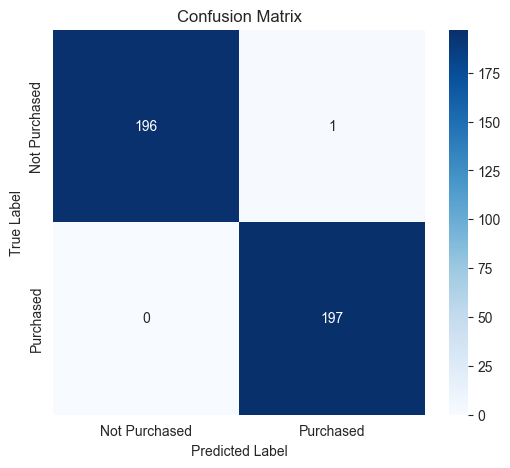


Top 10 Feature Importances:
                                     Feature  Importance
5                          ActivatedModules    0.085853
1375  Medius Territory_Medius North America    0.051626
13                        DistinctLanguages    0.047028
3                          Sum of ACV (USD)    0.037216
14                    AvgTimeToCompleteTask    0.024961
0                          Sum of Employees    0.024509
10                      AvgInvoicesPerMonth    0.023721
12                           AvgOverdueDays    0.022214
15                    TotalArchivedInvoices    0.021451
16                      OverdueInvoiceCount    0.020409
   Purchase_Probability
0                  0.01
1                  0.02
2                  0.00
3                  0.05
4                  0.11


In [10]:
# Import necessary libraries
import pandas as pd
import numpy as np
from collections import Counter
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Load Data
def split_features_target(df_encoded2, target_column="HasPay"):
    """Splits dataframe into features (X) and target variable (y)."""
    X = df_encoded2.drop(columns=[target_column])
    y = df_encoded2[target_column]
    return X, y

# 2. Check class distribution
def check_class_distribution(y):
    """Prints the class distribution of the target variable."""
    counter = Counter(y)
    print(f"Class distribution: {counter}")

# 3. Apply Oversampling
def apply_oversampling(X, y):
    """Applies Random Oversampling to balance the dataset."""
    oversampler = RandomOverSampler(random_state=42)
    X_resampled, y_resampled = oversampler.fit_resample(X, y)
    return X_resampled, y_resampled

# 4. Train and evaluate model
def train_and_evaluate(X, y):
    """Splits data, trains a model, and evaluates performance."""

    # Split into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    # Train Random Forest model
    model = RandomForestClassifier(random_state=42)
    model.fit(X_train, y_train)

    # Make predictions
    y_pred = model.predict(X_test)

    # Evaluate model performance
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print("\nModel Performance:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    return model, X_test, y_test, y_pred

# 5. Plot Confusion Matrix
def plot_confusion_matrix(y_true, y_pred):
    """Generates and plots a confusion matrix."""
    cm = confusion_matrix(y_true, y_pred)

    # Plot heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Not Purchased", "Purchased"], yticklabels=["Not Purchased", "Purchased"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title("Confusion Matrix")
    plt.show()

# 6. Get Feature Importances
def get_top_10_feature_importances(model, X):
    """Extracts and prints the top 10 most important features."""
    importances = model.feature_importances_
    feature_names = X.columns
    feature_importances = pd.DataFrame({"Feature": feature_names, "Importance": importances})
    feature_importances = feature_importances.sort_values(by="Importance", ascending=False).head(10)
    print("\nTop 10 Feature Importances:\n", feature_importances)

# 7. Apply Purchase Probability Prediction
def apply_purchase_probability(model, X):
    """Applies the trained model to predict the likelihood of each APA tenant purchasing Pay."""
    probabilities = model.predict_proba(X)[:, 1]  # Extract probability of class 1
    X_with_scores = X.copy()
    X_with_scores["Purchase_Probability"] = probabilities
    return X_with_scores

# %% EXECUTE PIPELINE

# Load data (assuming df_encoded is ready)
X, y = split_features_target(df_encoded2)

# Check initial class distribution
check_class_distribution(y)

# Apply Oversampling
X_resampled, y_resampled = apply_oversampling(X, y)

# Check new class distribution
check_class_distribution(y_resampled)

# Train and Evaluate Model
model, X_test, y_test, y_pred = train_and_evaluate(X_resampled, y_resampled)

# Plot Confusion Matrix
plot_confusion_matrix(y_test, y_pred)

# Get Top 10 Feature Importances
get_top_10_feature_importances(model, X_resampled)

# Apply Predict Proba to Get Likelihood Scores
X_with_scores = apply_purchase_probability(model, X_resampled)

# Display first few rows of likelihood scores
print(X_with_scores[['Purchase_Probability']].head())
